Custom modules:
Writing own nn.Module subclass with a custom forward method. Writing a custom loss function. Writing a custom optimizer (SGD from scratch using param.grad, then Adam). 

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
class Network(nn.Module):
    def __init__(self):
        super().__init__()
        self.f1 = nn.Linear(784, 128)
        self.rel = nn.ReLU()
        self.f2 = nn.Linear(128, 10)

    def forward(self, x):
        f1_out = self.f1(x)
        rel_out = self.rel(f1_out)
        return self.f2(rel_out)

Data Loading

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

Now that the nn.Module version is complete, we now move onto experimenting with a custom loss function
We'll write CrossEntropyLoss as an nn.Module subclass

In [4]:
model = Network()

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
loss_fn = nn.CrossEntropyLoss()
pytorch_loss = []
epochs = 5
lr = 0.05
for epoch in range(epochs):
    epoch_loss = 0
    for images, labels in train_loader:
        images = images.view(-1, 784)

        forward = model(images)
        loss = loss_fn(forward, labels)

        epoch_loss += loss

        loss.backward()

        with torch.no_grad():
            for param in model.parameters():
                param -= lr * param.grad

        for param in model.parameters():
            param.grad.zero_()

    print(f"Loss[{epoch}]: {epoch_loss}")
    pytorch_loss.append(epoch_loss.item())

Loss[0]: 485.2610168457031
Loss[1]: 212.74078369140625
Loss[2]: 148.0557861328125
Loss[3]: 111.14856719970703
Loss[4]: 88.19424438476562


In [5]:
class CEL(nn.Module):
    def forward(self, X, y):
        exps = torch.exp(X - torch.max(X, dim=1, keepdim=True).values)
        probs = exps / torch.sum(exps, dim=1, keepdim=True)
        class_probability = probs[torch.arange(X.shape[0]), y]
        return torch.mean(-1 * torch.log(class_probability))

Adding and comparing new CEL version of loss_fn

In [6]:
model = Network()

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
loss_fn = CEL()
cel_loss = []
epochs = 5
lr = 0.05
for epoch in range(epochs):
    epoch_loss = 0
    for images, labels in train_loader:
        images = images.view(-1, 784)

        forward = model(images)
        loss = loss_fn(forward, labels)

        epoch_loss += loss

        loss.backward()

        with torch.no_grad():
            for param in model.parameters():
                param -= lr * param.grad

        for param in model.parameters():
            param.grad.zero_()

    print(f"Loss[{epoch}]: {epoch_loss}")
    cel_loss.append(epoch_loss.item())



Loss[0]: 486.69482421875
Loss[1]: 216.45318603515625
Loss[2]: 150.0274200439453
Loss[3]: 114.31448364257812
Loss[4]: 89.14554595947266


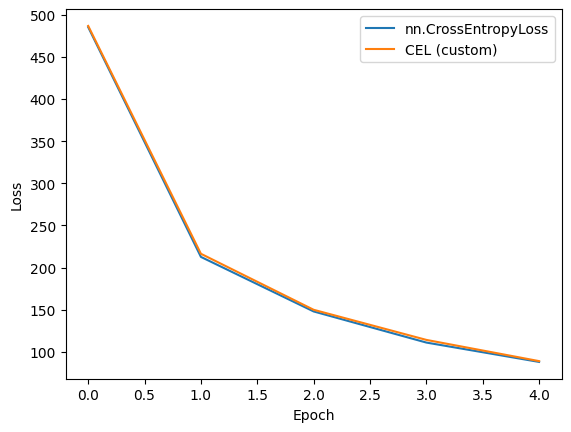

In [7]:
plt.plot([l.item() if hasattr(l, 'item') else l for l in pytorch_loss], label="nn.CrossEntropyLoss")
plt.plot(cel_loss, label="CEL (custom)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Next: Custom SGD optimizer

In [8]:
class SGD:
    def __init__(self, params, lr):
        self.params = list(params)
        self.lr = lr

    def step(self):
        with torch.no_grad():
            for param in self.params:
                param -= self.lr * param.grad

    def zero_grad(self):
        for param in self.params:
            param.grad.zero_()

Now rewriting training loop using SGD

In [9]:
model = Network()
optimizer = SGD(model.parameters(), lr=0.05)
loss_fn = nn.CrossEntropyLoss()
epochs = 5
for epoch in range(epochs):
    epoch_loss = 0
    for images, labels in train_loader:
        images = images.view(-1, 784)
        forward = model(images)
        loss = loss_fn(forward, labels)

        epoch_loss += loss

        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

    print(f"Loss[{epoch}]: {epoch_loss}")


Loss[0]: 481.9198303222656
Loss[1]: 210.8519744873047
Loss[2]: 147.15554809570312
Loss[3]: 111.1280288696289
Loss[4]: 86.5955581665039


Now to experiment with custom Adam optimizer

In [12]:
class Adam:
    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params = list(params)
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps

        self.m = [torch.zeros_like(p) for p in self.params]
        self.v = [torch.zeros_like(p) for p in self.params]

        self.t = 0

    def step(self):
        self.t += 1
        for i, param in enumerate(self.params):
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * param.grad
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (param.grad ** 2)

            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)

            with torch.no_grad():
                param -= self.lr * m_hat / (torch.sqrt(v_hat) + self.eps)
    
    def zero_grad(self):
        for param in self.params:
            param.grad.zero_()

Now we utilize Adam

In [13]:
model = Network()
optimizer = Adam(model.parameters())
loss_fn = nn.CrossEntropyLoss()
epochs = 5
for epoch in range(epochs):
    epoch_loss = 0
    for images, labels in train_loader:
        images = images.view(-1, 784)
        forward = model(images)
        loss = loss_fn(forward, labels)

        epoch_loss += loss

        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

    print(f"Loss[{epoch}]: {epoch_loss}")

Loss[0]: 429.5761413574219
Loss[1]: 193.66648864746094
Loss[2]: 138.83033752441406
Loss[3]: 108.60710906982422
Loss[4]: 85.49730682373047
